# Cifar-100 Classification with CNNs

Tesorflow version: 2.19.0
Training data (50000, 32, 32, 3)
Training label (50000, 1)
Max number of training label 99


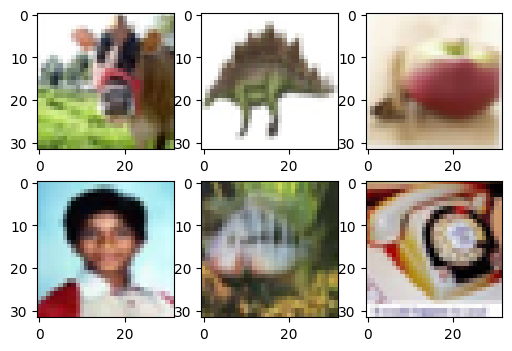

In [1]:
import tensorflow as tf
from keras.datasets import cifar100
from keras.layers import Dense, Flatten, Conv2D,  BatchNormalization, MaxPooling2D, Activation, Dropout, InputLayer
from keras.losses import categorical_crossentropy
from keras.utils import to_categorical
from keras.callbacks import Callback, EarlyStopping
from keras.optimizers import Adam
from keras.models import Sequential
from keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
print("Tesorflow version:", tf.__version__)

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar100.load_data()
print(f"Training data {X_train.shape}")
print(f"Training label {y_train.shape}")
print(f"Max number of training label {np.max(y_train)}")

import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 3, figsize=(6, 4))

for index, img in enumerate(X_train[0:6]):
    axs[int(index/3),index%3].imshow(img, cmap="gray_r")


## How to technically split and join the path through the network 


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Concatenate
from tensorflow.keras.models import Model

# Define the input layer
input_layer = Input(shape=(64, 64, 3))  # Example input shape (64, 64, 3)

# Split into two branches
conv1 = Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu')(input_layer)
conv2 = Conv2D(filters=32, kernel_size=(5, 5), padding='same', activation='relu')(input_layer)

# Concatenate the outputs of the two convolutional layers
concat_layer = Concatenate()([conv1, conv2])

# Create the model
model = Model(inputs=input_layer, outputs=concat_layer)

# Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 64, 64, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 64, 64, 32)        │             896 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 64, 64, 32)        │           2,432 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64, 64, 64)        │               0 │ conv2d[0][0],              │
│                               │                           │                 │ conv2d_1[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,328 (13.00 KB)

 Trainable params: 3,328 (13.00 KB)

 Non-trainable params: 0 (0.00 B)


## Exercise: Adding such a split into the existing model

This is not completley straight-forward, since the sequentical model will not directly accept a Concatenate-Layer. However there are some solutions to this.


In [ ]:
model = Sequential()
model.add(InputLayer(X_train.shape[1:]))
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(Activation('elu'))

model.add(Conv2D(128, (3, 3)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, (3, 3), padding='same'))
model.add(Activation('elu'))

model.add(Conv2D(256, (3, 3)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512, (3, 3), padding='same'))
model.add(Activation('elu'))

model.add(Conv2D(512, (3, 3)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(1024))
model.add(Activation('elu'))
model.add(Dropout(0.5))
model.add(Dense(100))
model.add(Activation('softmax'))
model.summary()

In [ ]:
opt=Adam(
    learning_rate=0.0001,
    beta_1=0.8,
    beta_2=0.999)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=100
)